In [34]:
import re
from io import StringIO
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

csv_dir = Path("csv")

def read_trials_csv(path):
    text = Path(path).read_text(encoding="utf-8")
    text = re.sub(r",(?=\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2},)", "\n", text)

    lines = text.splitlines()
    if not lines:
        return pd.DataFrame()

    valid_lines = [lines[0]]
    for line in lines[1:]:
        if line.count(",") >= 24:
            valid_lines.append(line)

    return pd.read_csv(StringIO("\n".join(valid_lines)), on_bad_lines="skip")


items = pd.concat(
    [pd.read_csv(f) for f in sorted(csv_dir.glob("*_items.csv"))],
    ignore_index=True
)
trials = pd.concat(
    [read_trials_csv(f) for f in sorted(csv_dir.glob("*_trials.csv"))],
    ignore_index=True
)
items = items.drop(columns=["chunk_label", "timestamp", "participant"], errors="ignore")


In [35]:
iex1 = items[(items["experiment"] == "free_recall") & (items["condition"] == "baseline")]
tex1 = trials[(trials["experiment"] == "free_recall") & (trials["condition"] == "baseline")]
iex2 = items[items["condition"] == "unfilled_delay"]
tex2 = trials[trials["condition"] == "unfilled_delay"]
iex3 = items[items["condition"] == "fast_rate"]
tex3 = trials[trials["condition"] == "fast_rate"]
iex4 = items[items["condition"] == "working_memory"]
tex4 = trials[trials["condition"] == "working_memory"]
iex5 = items[items["condition"].str.fullmatch(r"capacity_n\d")]
tex5 = trials[trials["condition"].str.fullmatch(r"capacity_n\d")]
iex6 = items[(items["experiment"] == "serial_recall") & (items["condition"] == "baseline")]
tex6 = trials[(trials["experiment"] == "serial_recall") & (trials["condition"] == "baseline")]
iex7 = items[items["condition"] == "finger_tapping"]
tex7 = trials[trials["condition"] == "finger_tapping"]
iex8 = items[items["condition"] == "articulatory_suppression"]
tex8 = trials[trials["condition"] == "articulatory_suppression"]
iex9 = items[(items["condition"] == "real_idioms") & (items["n_items"] == 8)]
tex9 = trials[trials["condition"] == "real_idioms"]
iex10 = items[(items["condition"] == "fake_idioms") & (items["n_items"] == 8)]
tex10 = trials[trials["condition"] == "fake_idioms"]


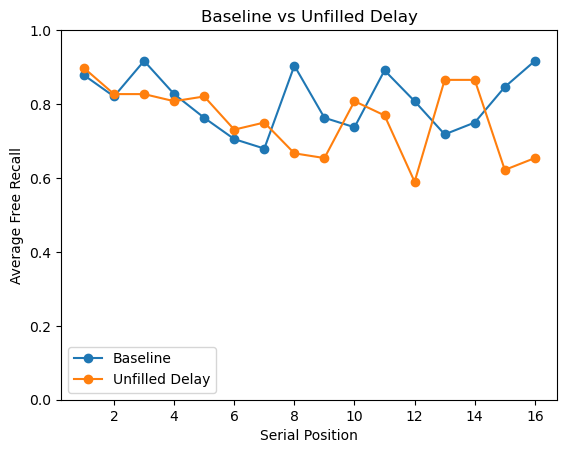

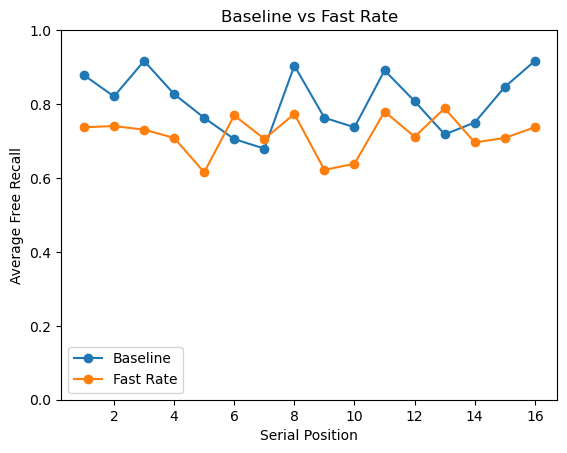

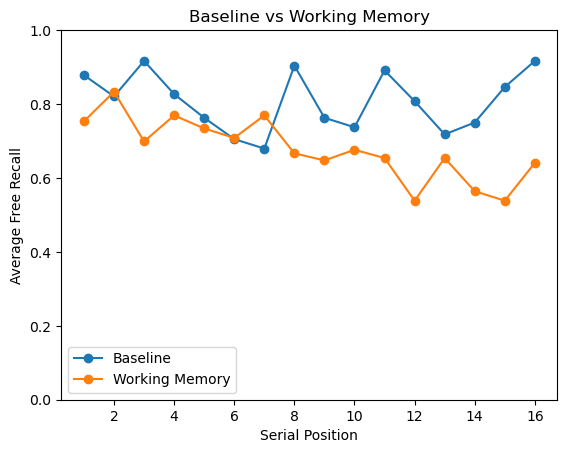

In [36]:
serial_curve1 = iex1.groupby("serial_position")["free_recalled"].mean()  # Baseline
serial_curve2 = iex2.groupby("serial_position")["free_recalled"].mean()  # Unfilled Delay
serial_curve3 = iex3.groupby("serial_position")["free_recalled"].mean()  # Fast Rate
serial_curve4 = iex4.groupby("serial_position")["free_recalled"].mean()  # Working Memory

# Graph 1: Baseline vs Unfilled Delay
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve2.index, serial_curve2.values, marker="o", label="Unfilled Delay")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.ylim(0, 1)
plt.title("Baseline vs Unfilled Delay")
plt.legend()
plt.show()

# Graph 2: Baseline vs Fast Rate
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve3.index, serial_curve3.values, marker="o", label="Fast Rate")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.ylim(0, 1)
plt.title("Baseline vs Fast Rate")
plt.legend()
plt.show()

# Graph 3: Baseline vs Working Memory
plt.plot(serial_curve1.index, serial_curve1.values, marker="o", label="Baseline")
plt.plot(serial_curve4.index, serial_curve4.values, marker="o", label="Working Memory")
plt.xlabel("Serial Position")
plt.ylabel("Average Free Recall")
plt.ylim(0, 1)
plt.title("Baseline vs Working Memory")
plt.legend()
plt.show()

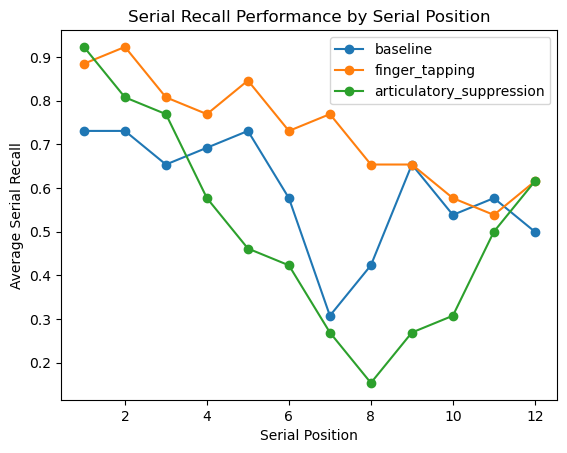

In [37]:
serial_curve6 = iex6.groupby("serial_position")["serial_correct"].mean()
serial_curve7 = iex7.groupby("serial_position")["serial_correct"].mean()
serial_curve8 = iex8.groupby("serial_position")["serial_correct"].mean()

plt.plot(serial_curve6.index, serial_curve6.values, marker="o", label="baseline")
plt.plot(serial_curve7.index, serial_curve7.values, marker="o", label="finger_tapping")
plt.plot(serial_curve8.index, serial_curve8.values, marker="o", label="articulatory_suppression")

plt.xlabel("Serial Position")
plt.ylabel("Average Serial Recall")
plt.title("Serial Recall Performance by Serial Position")
plt.legend()
plt.show()

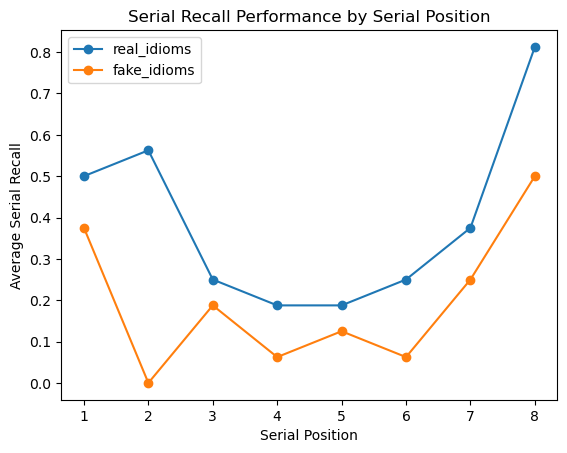

In [38]:
serial_curve9 = iex9.groupby("serial_position")["serial_correct"].mean()
serial_curve10 = iex10.groupby("serial_position")["serial_correct"].mean()

plt.plot(serial_curve9.index, serial_curve9.values, marker="o", label="real_idioms")
plt.plot(serial_curve10.index, serial_curve10.values, marker="o", label="fake_idioms")

plt.xlabel("Serial Position")
plt.ylabel("Average Serial Recall")
plt.title("Serial Recall Performance by Serial Position")
plt.legend()
plt.show()

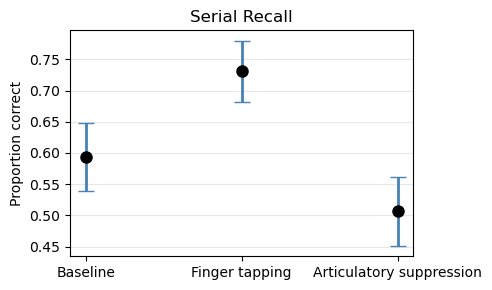

In [39]:
# The effect of articulatory suppression
# The (lack of) effect of finger tapping
def conf(data):
    data = data["serial_correct"]
    p = data.sum() / len(data)
    confidence_interval = [
        p - 1.96 * (p * (1 - p) / len(data)) ** 0.5,
        p + 1.96 * (p * (1 - p) / len(data)) ** 0.5
    ]
    return p, confidence_interval[0], confidence_interval[1]

datasets = {"Baseline": iex6, "Finger tapping": iex7, "Articulatory suppression": iex8}

labels, estimates, err_low, err_high = [], [], [], []

for name, d in datasets.items():
    p, lo, hi = conf(d)
    labels.append(name)
    estimates.append(p)
    err_low.append(p - lo)
    err_high.append(hi - p)

fig, ax = plt.subplots(figsize=(5, 3))
ax.errorbar(
    labels, estimates, yerr=[err_low, err_high],
    fmt='o', capsize=6, markersize=8,
    color='black', ecolor='steelblue', elinewidth=2
)
ax.set_ylabel("Proportion correct")
ax.set_title("Serial Recall")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# The effect of chunking
lettercount6 = iex6[iex6['serial_correct'] == 1]["presented_item"].str.len().sum()
experimentcount6 = len(iex6)/12
lettercount9 = iex9[iex9['serial_correct'] == 1]["presented_item"].str.len().sum()
lettercount10 = iex10[iex10['serial_correct'] == 1]["presented_item"].str.len().sum()
experimentcount9 = len(iex9)/12
experimentcount10 = len(iex10)/12
print(lettercount6/experimentcount6, lettercount9/experimentcount9, lettercount10/experimentcount10)

7.115384615384615 101.625 63.5625


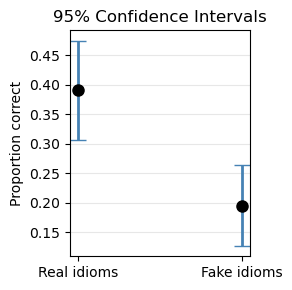

In [41]:
datasets = {"Real idioms": iex9, "Fake idioms": iex10}

labels, estimates, err_low, err_high = [], [], [], []

for name, d in datasets.items():
    p, lo, hi = conf(d)
    labels.append(name)
    estimates.append(p)
    err_low.append(p - lo)
    err_high.append(hi - p)

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    labels, estimates, yerr=[err_low, err_high],
    fmt='o', capsize=6, markersize=8,
    color='black', ecolor='steelblue', elinewidth=2
)
ax.set_ylabel("Proportion correct")
ax.set_title("95% Confidence Intervals")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()